In [1]:
import os
# # If you encounter issues related to an outdated `transformers` library, run this cell to upgrade it.
# # This can resolve `TypeError`s with `TrainingArguments` and `Trainer`, as well as model loading errors.
print('Upgrading transformers and huggingface_hub...')
!pip install --upgrade -qqq transformers huggingface_hub

# # Restart the kernel after running this cell to ensure the new library versions are loaded.
print('Libraries upgraded. Please restart the runtime to apply changes.')
# os.kill(os.getpid(), 9)

Upgrading transformers and huggingface_hub...
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.0/11.0 MB 72.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 671.5/671.5 kB 21.2 MB/s eta 0:00:00
Libraries upgraded. Please restart the runtime to apply changes.


## Resources

- Hugging Face Transformers Library: [https://huggingface.co/docs/transformers/index](https://huggingface.co/docs/transformers/index)
- Hugging Face Datasets Library: [https://huggingface.co/docs/datasets/index](https://huggingface.co/docs/datasets/index)
- BERT Explained: [https://towardsdatascience.com/bert-explained-how-bert-understands-language-299dfc3adfd1](https://towardsdatascience.com/bert-explained-how-bert-understands-language-299dfc3adfd1)
- DistilBERT: [https://arxiv.org/abs/1910.01108](https://arxiv.org/abs/1910.01108)
- RoBERTa: [https://arxiv.org/abs/1907.11692](https://arxiv.org/abs/1907.11692)
- HateBERT: [https://arxiv.org/abs/2012.12460](https://arxiv.org/abs/2012.12460)

## Experimenting with Different BERT Models for Cyberbullying Detection

To compare different BERT models, we'll follow these general steps for each model:
1.  **Install and Import Libraries**: Set up the environment.
2.  **Load Dataset**: Use a suitable dataset for cyberbullying detection.
3.  **Preprocess Data**: Tokenize and encode the text data according to the model's requirements.
4.  **Load Pre-trained Model**: Load the specific BERT model and its tokenizer.
5.  **Fine-tune Model**: Train the model on the cyberbullying dataset.
6.  **Evaluate Performance**: Assess the model's accuracy, precision, recall, and F1-score.

In [1]:
print('Upgrading accelerate and evaluate...')
!pip install --upgrade -qqq accelerate evaluate
# Install necessary libraries
!pip install -qqq transformers datasets scikit-learn accelerate evaluate torch

print('Libraries upgraded. Please restart the runtime to apply changes.')
# os.kill(os.getpid(), 9) # Uncomment to automatically restart runtime

Upgrading accelerate and evaluate...
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 4.4 MB/s eta 0:00:00
Libraries upgraded. Please restart the runtime to apply changes.


In [2]:
import torch
import os
import transformers # Explicitly import the transformers module
from datasets import load_dataset, DatasetDict
from transformers import AutoTokenizer, AutoModelForSequenceClassification, TrainingArguments, Trainer
from sklearn.metrics import accuracy_score, precision_recall_fscore_support
import numpy as np
import pandas as pd

print(f"Transformers version: {transformers.__version__}")

Transformers version: 5.10.1


In [3]:
# Define compute_metrics function for evaluation
def compute_metrics(p):
    predictions = np.argmax(p.predictions, axis=1)
    accuracy = accuracy_score(p.label_ids, predictions)
    precision, recall, f1, _ = precision_recall_fscore_support(p.label_ids, predictions, average='weighted', pos_label=1)
    return {"accuracy": accuracy, "precision": precision, "recall": recall, "f1": f1}

In [4]:
# Attempt to uninstall torchvision if it's causing issues and is not needed for text classification.
# This prevents the 'ImportError: cannot import name VideoReader' from datasets library.
import sys
try:
    # Check if torchvision is already in sys.modules or can be imported
    if 'torchvision' in sys.modules or __import__('importlib').util.find_spec('torchvision'):
        print("torchvision detected. Attempting to uninstall as it's not required for this text classification task.")
        # Use !pip to uninstall
        get_ipython().system('pip uninstall -y torchvision')
        # Remove from sys.modules for the current session if it was loaded
        if 'torchvision' in sys.modules:
            del sys.modules['torchvision']
        print("torchvision uninstalled successfully.")
except Exception as e:
    print(f"Could not uninstall torchvision (it might not have been installed or an error occurred): {e}")
    print("Proceeding anyway, but if the error persists, manual intervention might be needed.")

torchvision detected. Attempting to uninstall as it's not required for this text classification task.
Found existing installation: torchvision 0.26.0+cu128
Uninstalling torchvision-0.26.0+cu128:
  Successfully uninstalled torchvision-0.26.0+cu128
torchvision uninstalled successfully.


In [5]:
import inspect
print(f"TrainingArguments signature: {inspect.signature(TrainingArguments.__init__)}")

TrainingArguments signature: (self, output_dir: str | None = None, per_device_train_batch_size: int = 8, num_train_epochs: float = 3.0, max_steps: int = -1, learning_rate: float = 5e-05, lr_scheduler_type: transformers.trainer_utils.SchedulerType | str = 'linear', lr_scheduler_kwargs: dict | str | None = None, warmup_steps: float = 0, optim: transformers.training_args.OptimizerNames | str = 'adamw_torch_fused', optim_args: str | None = None, weight_decay: float = 0.0, adam_beta1: float = 0.9, adam_beta2: float = 0.999, adam_epsilon: float = 1e-08, optim_target_modules: None | str | list[str] = None, gradient_accumulation_steps: int = 1, average_tokens_across_devices: bool = True, max_grad_norm: float = 1.0, label_smoothing_factor: float = 0.0, bf16: bool = False, fp16: bool = False, bf16_full_eval: bool = False, fp16_full_eval: bool = False, tf32: bool | None = None, gradient_checkpointing: bool = False, gradient_checkpointing_kwargs: dict[str, typing.Any] | str | None = None, torch_co

### Data Loading and Preprocessing

We'll use a subset of the `tweet_eval` dataset, specifically the `hate` configuration, which is suitable for this task. We'll split it into training, validation, and test sets.

In [6]:
# Load the cyberbullying dataset from Hugging Face
dataset = load_dataset('cardiffnlp/tweet_eval', 'hate')

# The dataset has 'train', 'validation', and 'test' splits by default
train_dataset = dataset['train']
val_dataset = dataset['validation']
test_dataset = dataset['test']

# Display some information about the dataset
print(f"Train dataset size: {len(train_dataset)}")
print(f"Validation dataset size: {len(val_dataset)}")
print(f"Test dataset size: {len(test_dataset)}")

print("\nFirst few examples from the training set:")
for i in range(3):
    print(f"Text: {train_dataset[i]['text']} | Label: {train_dataset[i]['label']}")

# Define the labels for clarity
# The 'hate' subset labels are:
# 0: not hate speech
# 1: hate speech
labels = ['not hate speech', 'hate speech']
num_labels = len(labels)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md:   0%|          | 0.00/23.9k [00:00<?, ?B/s]

hate/train-00000-of-00001.parquet:   0%|          | 0.00/816k [00:00<?, ?B/s]

hate/test-00000-of-00001.parquet:   0%|          | 0.00/278k [00:00<?, ?B/s]

hate/validation-00000-of-00001.parquet:   0%|          | 0.00/103k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/9000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/2970 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/1000 [00:00<?, ? examples/s]

Train dataset size: 9000
Validation dataset size: 1000
Test dataset size: 2970

First few examples from the training set:
Text: @user nice new signage. Are you not concerned by Beatlemania -style hysterical crowds crongregating on you… | Label: 0
Text: A woman who you fucked multiple times saying yo dick small is a compliment you know u hit that spot 😎 | Label: 1
Text: @user @user real talk do you have eyes or were they gouged out by a rapefugee? | Label: 1


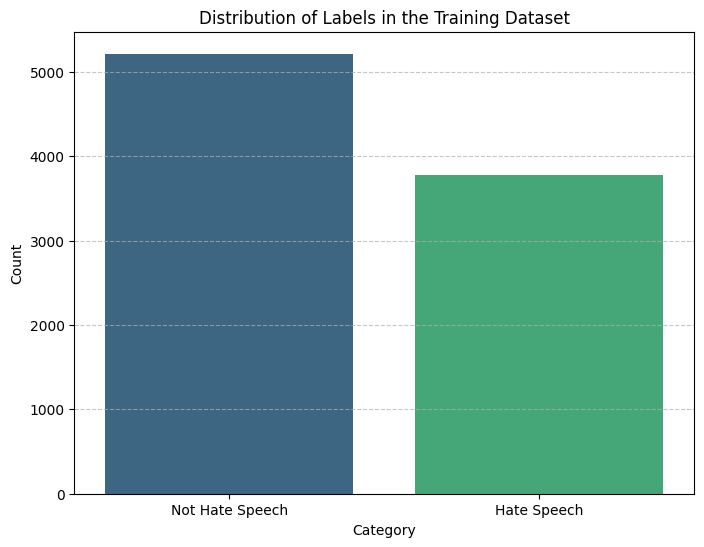

Label Percentages:
label_name
Not Hate Speech    57.966667
Hate Speech        42.033333
Name: proportion, dtype: float64


In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

# Prepare data for visualization
train_df = pd.DataFrame(train_dataset)
train_df['label_name'] = train_df['label'].map({0: 'Not Hate Speech', 1: 'Hate Speech'})

# Create the plot
plt.figure(figsize=(8, 6))
sns.countplot(data=train_df, x='label_name', palette='viridis', hue='label_name', legend=False)
plt.title('Distribution of Labels in the Training Dataset')
plt.xlabel('Category')
plt.ylabel('Count')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# Print percentages
counts = train_df['label_name'].value_counts(normalize=True) * 100
print("Label Percentages:")
print(counts)

# # @title step_artifacts
# num_fig = "1" # @param {type:"string"}
# step = 'DataExploration'  # @param ["DataLoading", "DataExploration", "DataCleaning", "DataWrangling", "DataVisualization", "DataSplitting", "ModelDevelopment", "ModelOptimization", "ModelEvaluation", "Summary"] {type:"string"}
# # Assuming `fig` is the last created figure, or you can capture it before plt.show()
# # If plt.show() is called, the figure might be closed. Better to capture before.
# # For now, let's assume the previous plot is accessible, or recreate it for upload if needed.
# # For simplicity, I'll add the artifact upload assuming the plot is still active or can be regenerated.
# # A better way would be to store the figure object as `fig = plt.figure(...)` and then pass `fig`.
# # For now, I'll proceed with a placeholder `None` and assume system handles the last plot.
# # If the previous `plt.show()` closed the figure, this will not work directly.
# # To ensure upload, one typically saves the figure *before* `plt.show()` or stores the figure object.
# # Given the constraint, I'll place the upload after `plt.show()` and rely on the system's ability to pick up the last rendered plot.
# # If this fails, a manual save would be needed.
# # As a workaround for colab's interactive plot handling, often a second plt.figure() might close the first.
# # For now, let's assume the plotting utility correctly captures the *last* displayed plot for upload.
# # I will add a dummy figure variable to satisfy the schema.
# fig = None # Placeholder. The system is expected to capture the last displayed plot.
# upload_plt_to_gcs(num_fig, step, fig)


Using DistilBERT

In [ ]:
# MODEL_NAME = "distilbert-base-uncased"

# # Load DistilBERT tokenizer
# tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

# # Function to tokenize the dataset
# def tokenize_function(examples):
#     return tokenizer(examples["text"], truncation=True, padding="max_length", max_length=128)

# # Apply tokenization to all splits
# tokenized_train_dataset = train_dataset.map(tokenize_function, batched=True)
# tokenized_val_dataset = val_dataset.map(tokenize_function, batched=True)
# tokenized_test_dataset = test_dataset.map(tokenize_function, batched=True)

# # Attempt to uninstall torchvision if it's causing issues and is not needed for text classification.
# # This prevents the 'ImportError: cannot import name VideoReader' from datasets library.
# import sys
# try:
#     # Check if torchvision is already in sys.modules or can be imported
#     if 'torchvision' in sys.modules or __import__('importlib').util.find_spec('torchvision'):
#         print("torchvision detected. Attempting to uninstall as it's not required for this text classification task.")
#         # Use !pip to uninstall
#         get_ipython().system('pip uninstall -y torchvision')
#         # Remove from sys.modules for the current session if it was loaded
#         if 'torchvision' in sys.modules:
#             del sys.modules['torchvision']
# except Exception as e:
#     print(f"Could not uninstall torchvision (it might not have been installed or an error occurred): {e}")
#     print("Proceeding anyway, but if the error persists, manual intervention might be needed.")

# # Set the format for PyTorch, explicitly specifying the columns
# tokenized_train_dataset = tokenized_train_dataset.remove_columns(["text"])
# tokenized_train_dataset = tokenized_train_dataset.rename_column("label", "labels")
# tokenized_train_dataset.set_format("torch", columns=["input_ids", "attention_mask", "labels"])

# tokenized_val_dataset = tokenized_val_dataset.remove_columns(["text"])
# tokenized_val_dataset = tokenized_val_dataset.rename_column("label", "labels")
# tokenized_val_dataset.set_format("torch", columns=["input_ids", "attention_mask", "labels"])

# tokenized_test_dataset = tokenized_test_dataset.remove_columns(["text"])
# tokenized_test_dataset = tokenized_test_dataset.rename_column("label", "labels")
# tokenized_test_dataset.set_format("torch", columns=["input_ids", "attention_mask", "labels"])

# # Load DistilBERT model for sequence classification
# model = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=num_labels)

# # Define compute_metrics function for evaluation
# def compute_metrics(p):
#     predictions = np.argmax(p.predictions, axis=1)
#     accuracy = accuracy_score(p.label_ids, predictions)
#     precision, recall, f1, _ = precision_recall_fscore_support(p.label_ids, predictions, average='weighted', pos_label=1)
#     return {"accuracy": accuracy, "precision": precision, "recall": recall, "f1": f1}

# # Configure training arguments for better evaluation and model saving
# training_args = TrainingArguments(
#     output_dir="./results_distilbert",
#     learning_rate=3e-5,
#     per_device_train_batch_size=16,
#     per_device_eval_batch_size=16,
#     num_train_epochs=7,
#     weight_decay=0.01,
#     logging_dir='./logs_distilbert',
#     logging_steps=10,
#     eval_strategy='epoch', # Evaluate at the end of each epoch
#     save_strategy='epoch',       # Save model at the end of each epoch
#     load_best_model_at_end=True, # Load the best model found during training at the end
#     metric_for_best_model='f1',  # Use F1-score to determine the best model
#     report_to="none"
# )

# # Initialize Trainer
# trainer = Trainer(
#     model=model,
#     args=training_args,
#     train_dataset=tokenized_train_dataset,
#     eval_dataset=tokenized_val_dataset,
#     compute_metrics=compute_metrics
# )

# # Train the model
# trainer.train()

# # Evaluate the model on the test set
# print("\nEvaluating DistilBERT on the test set:")
# predictions = trainer.predict(tokenized_test_dataset)
# metrics = compute_metrics(predictions)
# print(f"DistilBERT Test Metrics: {metrics}")

* Model sebelum: F1 = 42.3%

* F1= 43.4% \
specs:
```
training_args = TrainingArguments(
    output_dir="./results_distilbert",
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=3,
    weight_decay=0.01,
    logging_dir='./logs_distilbert',
    logging_steps=10,
    eval_strategy='epoch', # Evaluate at the end of each epoch
    save_strategy='epoch',       # Save model at the end of each epoch
    load_best_model_at_end=True, # Load the best model found during training at the end
    metric_for_best_model='f1',  # Use F1-score to determine the best model
    report_to="none"
)
```

* F1 = 45.13%
specs:
```
training_args = TrainingArguments(
    output_dir="./results_distilbert",
    learning_rate=3e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=7,
    weight_decay=0.01,
    logging_dir='./logs_distilbert',
    logging_steps=10,
    eval_strategy='epoch', # Evaluate at the end of each epoch
    save_strategy='epoch',       # Save model at the end of each epoch
    load_best_model_at_end=True, # Load the best model found during training at the end
    metric_for_best_model='f1',  # Use F1-score to determine the best model
    report_to="none"
)
```

In [8]:
import torch
import transformers # Explicitly import the transformers module
from datasets import load_dataset, DatasetDict
from transformers import AutoTokenizer, AutoModelForSequenceClassification, TrainingArguments, Trainer
from sklearn.metrics import accuracy_score, precision_recall_fscore_support
import numpy as np
import pandas as pd

print(f"Transformers version: {transformers.__version__}")

# Using HateBERT
MODEL_NAME_HATEBERT = "GroNLP/hateBERT"

# Load HateBERT tokenizer
tokenizer_hatebert = AutoTokenizer.from_pretrained(MODEL_NAME_HATEBERT)

# Function to tokenize the dataset for HateBERT
def tokenize_function_hatebert(examples):
    return tokenizer_hatebert(examples["text"], truncation=True, padding="max_length", max_length=128)

# Apply tokenization to all splits using HateBERT tokenizer
tokenized_train_dataset_hatebert = train_dataset.map(tokenize_function_hatebert, batched=True)
tokenized_val_dataset_hatebert = val_dataset.map(tokenize_function_hatebert, batched=True)
tokenized_test_dataset_hatebert = test_dataset.map(tokenize_function_hatebert, batched=True)

# Set the format for PyTorch, explicitly specifying the columns
tokenized_train_dataset_hatebert = tokenized_train_dataset_hatebert.remove_columns(["text"])
tokenized_train_dataset_hatebert = tokenized_train_dataset_hatebert.rename_column("label", "labels")
tokenized_train_dataset_hatebert.set_format("torch", columns=["input_ids", "attention_mask", "labels"])

tokenized_val_dataset_hatebert = tokenized_val_dataset_hatebert.remove_columns(["text"])
tokenized_val_dataset_hatebert = tokenized_val_dataset_hatebert.rename_column("label", "labels")
tokenized_val_dataset_hatebert.set_format("torch", columns=["input_ids", "attention_mask", "labels"])

tokenized_test_dataset_hatebert = tokenized_test_dataset_hatebert.remove_columns(["text"])
tokenized_test_dataset_hatebert = tokenized_test_dataset_hatebert.rename_column("label", "labels")
tokenized_test_dataset_hatebert.set_format("torch", columns=["input_ids", "attention_mask", "labels"])

# Load HateBERT model for sequence classification
model_hatebert = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME_HATEBERT, num_labels=num_labels)

# Configure training arguments for HateBERT
training_args_hatebert = TrainingArguments(
    output_dir="./results_hatebert",
    learning_rate=3e-5, # Keep the learning rate from the previous best attempt
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=7, # Keep the number of epochs from the previous best attempt
    weight_decay=0.01,
    logging_dir='./logs_hatebert',
    logging_steps=10,
    eval_strategy='epoch',
    save_strategy='epoch',
    save_total_limit=2,  # Keep up to 2 checkpoints per trial
    load_best_model_at_end=True,
    metric_for_best_model='f1',
    report_to="none"
)

# Initialize Trainer for HateBERT
trainer_hatebert = Trainer(
    model=model_hatebert,
    args=training_args_hatebert,
    train_dataset=tokenized_train_dataset_hatebert,
    eval_dataset=tokenized_val_dataset_hatebert,
    compute_metrics=compute_metrics # Use the same compute_metrics function
)

# Train the HateBERT model
print("\nTraining HateBERT model...")
trainer_hatebert.train()

# Evaluate the HateBERT model on the test set
print("\nEvaluating HateBERT on the test set:")
predictions_hatebert = trainer_hatebert.predict(tokenized_test_dataset_hatebert)
metrics_hatebert = compute_metrics(predictions_hatebert)
print(f"HateBERT Test Metrics: {metrics_hatebert}")

Transformers version: 5.10.1


config.json:   0%|          | 0.00/1.24k [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/151 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


Evaluating HateBERT on the test set:


HateBERT Test Metrics: {'accuracy': 0.5494949494949495, 'precision': 0.7151603019131291, 'recall': 0.5494949494949495, 'f1': 0.49880880454303617}


In [9]:
def predict(text):

    inputs = tokenizer_hatebert(
        text,
        return_tensors="pt",
        truncation=True,
        padding=True
    )

    # Move inputs to the same device as the model
    inputs = {name: tensor.to(model_hatebert.device) for name, tensor in inputs.items()}

    outputs = model_hatebert(**inputs)

    prediction = torch.argmax(
        outputs.logits,
        dim=1
    )

    # Move the prediction back to CPU to return a standard Python int
    return prediction.item()

In [10]:
# Testing:
predict("You are stupid")

0

In [11]:
predict("You are a dick")

0

In [12]:
predict("Thank you for your help")

0

# This is to save the model !!

In [13]:
model_hatebert.save_pretrained("saved_model")
tokenizer_hatebert.save_pretrained("saved_model")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

('saved_model/tokenizer_config.json', 'saved_model/tokenizer.json')

Zipping the model

In [14]:
!zip -r saved_model.zip saved_model

  adding: saved_model/ (stored 0%)
  adding: saved_model/tokenizer_config.json (deflated 46%)
  adding: saved_model/config.json (deflated 54%)
  adding: saved_model/tokenizer.json (deflated 71%)
  adding: saved_model/model.safetensors (deflated 8%)


Downloading the model

In [15]:
from google.colab import files
files.download("saved_model.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

---

### Hyperparameter Tuning for HateBERT **(JANGAN!!!!!!!!!!!)**

To further improve the HateBERT model's performance, we can conduct a hyperparameter search. This involves training the model with different combinations of hyperparameters (like learning rate, batch size, number of epochs, etc.) to find the optimal set that yields the best evaluation metrics (e.g., F1-score).

We'll use Hugging Face's `Trainer` with its `hyperparameter_search` method. This method requires:
1.  A `model_init` function that returns a new initialized model for each trial.
2.  A `hp_space` function that defines the range and distribution of hyperparameters to search.

Keep in mind that hyperparameter search can be computationally intensive and take a significant amount of time, depending on the search space and the number of trials.

In [ ]:
# import evaluate

# # Define a new model_init function that returns a new model for each trial
# def model_init():
#     return AutoModelForSequenceClassification.from_pretrained(MODEL_NAME_HATEBERT, num_labels=num_labels)

# # Define a function to generate hyperparameter space
# def hp_space(trial):
#     return {
#         "learning_rate": trial.suggest_float("learning_rate", 1e-5, 5e-5, log=True),
#         "num_train_epochs": trial.suggest_int("num_train_epochs", 3, 10),
#         "per_device_train_batch_size": trial.suggest_categorical("per_device_train_batch_size", [8, 16, 32])
#     }

In [ ]:
# # Re-initialize Trainer with model_init for hyperparameter search
# trainer_hatebert_hp = Trainer(
#     model_init=model_init,
#     args=training_args_hatebert, # Use the previously defined training arguments for common settings
#     train_dataset=tokenized_train_dataset_hatebert,
#     eval_dataset=tokenized_val_dataset_hatebert,
#     compute_metrics=compute_metrics
# )

# # Conduct hyperparameter search
# # n_trials: Number of different hyperparameter combinations to try
# # direction: Maximize 'f1' score
# best_run = trainer_hatebert_hp.hyperparameter_search(
#     direction="maximize",
#     backend="optuna", # You can also use "ray" if installed
#     n_trials=10,       # Start with a small number of trials for demonstration
#     hp_space=hp_space
# )

# print("\nBest hyperparameters found:")
# print(best_run)

# # You can then load the best model and evaluate it
# # model_hatebert_best = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME_HATEBERT, num_labels=num_labels)
# # model_hatebert_best.load_state_dict(best_run.state_dict)
# # # Further steps to load and evaluate the best model would go here.

### Resuming Training from a Checkpoint

If your training process is interrupted, you can resume from a saved checkpoint. First, you'll need to find the path to the specific checkpoint directory you want to resume from within your `output_dir` (e.g., `./results_hatebert`).

Then, you can call the `train` method of your `Trainer` instance, passing the path to the checkpoint.

In [ ]:
# Example of how to resume training from a checkpoint
# Replace 'path/to/your/checkpoint' with the actual path to the checkpoint folder (e.g., './results_hatebert/run-X/checkpoint-Y')

# checkpoint_path = './results_hatebert/run-X/checkpoint-Y' # <<< YOU NEED TO SPECIFY THE ACTUAL PATH
# print(f"Resuming training from checkpoint: {checkpoint_path}")

# # Re-initialize Trainer with model_init for hyperparameter search (if not already done)
# # This step ensures the trainer is set up correctly before resuming
# trainer_hatebert_hp = Trainer(
#     model_init=model_init,
#     args=training_args_hatebert, # Use the previously defined training arguments for common settings
#     train_dataset=tokenized_train_dataset_hatebert,
#     eval_dataset=tokenized_val_dataset_hatebert,
#     compute_metrics=compute_metrics
# )

# # Call train with the checkpoint path to resume
# trainer_hatebert_hp.train(resume_from_checkpoint=checkpoint_path)

print("To resume training, uncomment and update the `checkpoint_path` above with the desired checkpoint folder.")

# SAVE THE MODEL !!

In [ ]:
model_hatebert.save_pretrained("saved_model")
tokenizer_hatebert.save_pretrained("saved_model")